In [29]:
import numpy as np
from matplotlib import pyplot as plt
import pandas as pd

In [30]:

df = pd.read_excel("/Users/jaworskj/Desktop/Bnet_thermal_bscans_results/Model_perfomance_small_part_only.xlsx")

In [31]:
import re
import pandas as pd

analysis_df = df.copy()
configuration_column = "Unnamed: 0"

labels = (
    analysis_df[configuration_column]
    .astype(str)
    .str.strip()
    .str.replace(r"\s+", " ", regex=True)
)

MODEL_ORDER = [
    "Bnet-Mean",
    "Bnet-Vertical projection",
    "Bnet-Deeper regressor",
    "Bnet-End refinement",
]

parsed_modes = []
parsed_projections = []
parsed_models = []

current_mode = None
current_projection = None

for label in labels:
    label_lower = label.lower()

    # Detect the beginning of a new projection block
    block_match = re.fullmatch(
        r"(h\s*\+\s*c|c)\s+(no|cosine|log1p)\s+projection",
        label_lower,
    )

    if block_match:
        current_mode = (
            "H+C"
            if re.fullmatch(r"h\s*\+\s*c", block_match.group(1))
            else "C"
        )

        projection_name = block_match.group(2)

        current_projection = {
            "no": "No projection",
            "cosine": "Cosine projection",
            "log1p": "Log1p projection",
        }[projection_name]

        # This row identifies the block, not one of the four selected models
        parsed_modes.append(current_mode)
        parsed_projections.append(current_projection)
        parsed_models.append(pd.NA)
        continue

    # Identify the network
    if "bnet-mean" in label_lower:
        model = "Bnet-Mean"
    elif "bnet-vertical projection" in label_lower:
        model = "Bnet-Vertical projection"
    elif "bnet-deeper regressor" in label_lower:
        model = "Bnet-Deeper regressor"
    elif "bnet-end refinement" in label_lower:
        model = "Bnet-End refinement"
    else:
        model = pd.NA

    # Read the mode from the model label when possible
    if re.search(r"h\s*\+\s*c\s*$", label_lower):
        mode = "H+C"
    elif re.search(r"\bc\s*$", label_lower):
        mode = "C"
    else:
        mode = current_mode

    parsed_modes.append(mode)
    parsed_projections.append(current_projection)
    parsed_models.append(model)

analysis_df["Analysis mode"] = parsed_modes
analysis_df["Projection"] = parsed_projections
analysis_df["Analysis model"] = parsed_models

# Keep only four networks, two acquisition modes, and no projection
iou_df = analysis_df.loc[
    analysis_df["Analysis model"].isin(MODEL_ORDER)
    & analysis_df["Analysis mode"].isin(["C", "H+C"])
    & analysis_df["Projection"].eq("No projection")
].copy()

iou_df["Analysis model"] = pd.Categorical(
    iou_df["Analysis model"],
    categories=MODEL_ORDER,
    ordered=True,
)

iou_df["Analysis mode"] = pd.Categorical(
    iou_df["Analysis mode"],
    categories=["C", "H+C"],  # C left, H+C right
    ordered=True,
)

iou_df = iou_df.sort_values(
    ["Analysis model", "Analysis mode"]
).reset_index(drop=True)

print("Rows retained:", len(iou_df))

coverage = (
    iou_df.groupby(
        ["Analysis model", "Analysis mode"],
        observed=False,
    )
    .size()
    .unstack(fill_value=0)
)

display(coverage)

display(
    iou_df[
        [
            configuration_column,
            "Analysis model",
            "Analysis mode",
            "Projection",
        ]
    ]
)

Rows retained: 8


Analysis mode,C,H+C
Analysis model,,
Bnet-Mean,1,1
Bnet-Vertical projection,1,1
Bnet-Deeper regressor,1,1
Bnet-End refinement,1,1


,Unnamed: 0,Analysis model,Analysis mode,Projection
0,Bnet-Mean C,Bnet-Mean,C,No projection
1,Bnet-Mean H+C,Bnet-Mean,H+C,No projection
2,Bnet-Vertical projection C,Bnet-Vertical projection,C,No projection
3,Bnet-Vertical projection H+C,Bnet-Vertical projection,H+C,No projection
4,Bnet-Deeper regressor C,Bnet-Deeper regressor,C,No projection
5,Bnet-Deeper regressor H+C,Bnet-Deeper regressor,H+C,No projection
6,Bnet-End refinement C,Bnet-End refinement,C,No projection
7,Bnet-End refinement H+C,Bnet-End refinement,H+C,No projection


IoU columns used:
Validation {'Best': ' Best IOU', 'Worst': 'Worst IOU', 'Median': None}
Test {'Best': 'Best IOU', 'Worst': 'Worst IOU.1', 'Median': None}
Number of plotted ranges: 16


,Model,Mode,Dataset,Worst IoU,Best IoU,Median IoU
0,Bnet-Mean,C,Validation,0.79,0.90,NaN
1,Bnet-Mean,C,Test,0.64,0.87,NaN
2,Bnet-Mean,H+C,Validation,0.85,0.92,NaN
3,Bnet-Mean,H+C,Test,0.73,0.91,NaN
4,Bnet-Vertical projection,C,Validation,0.84,0.90,NaN


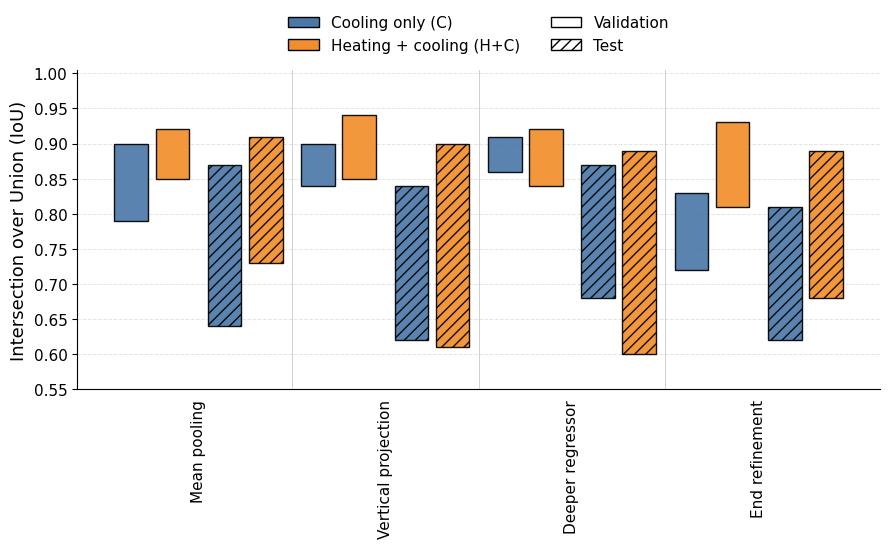

In [32]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle, Patch

# ---------------------------------------------------------
# Publication styling
# ---------------------------------------------------------
COLORS = {
    "C": "#4C78A8",      # blue
    "H+C": "#F28E2B",    # orange
}

MODEL_LABELS = {
    "Bnet-Mean": "Mean pooling",
    "Bnet-Vertical projection": "Vertical projection",
    "Bnet-Deeper regressor": "Deeper regressor",
    "Bnet-End refinement": "End refinement",
}

MODEL_ORDER = list(MODEL_LABELS.keys())
MODE_ORDER = ["C", "H+C"]
DATASET_ORDER = ["Validation", "Test"]


# ---------------------------------------------------------
# Find the appropriate IoU columns
# The second repeated Excel column is usually renamed ".1"
# by pandas.
# ---------------------------------------------------------
def find_column(candidates, required=True):
    for column in candidates:
        if column in iou_df.columns:
            return column

    if required:
        raise KeyError(
            f"None of these columns were found: {candidates}\n"
            f"Available IoU columns: "
            f"{[c for c in iou_df.columns if 'iou' in str(c).lower()]}"
        )

    return None


iou_columns = {
    "Validation": {
        "Best": " Best IOU",   # leading space is present
        "Worst": "Worst IOU",
        "Median": None,
    },
    "Test": {
        "Best": "Best IOU",
        "Worst": "Worst IOU.1",
        "Median": None,
    },
}

print("IoU columns used:")
for dataset, columns in iou_columns.items():
    print(dataset, columns)


# ---------------------------------------------------------
# Convert the selected dataframe to long format
# ---------------------------------------------------------
plot_records = []

for _, row in iou_df.iterrows():
    model = row["Analysis model"]
    mode = row["Analysis mode"]

    for dataset in DATASET_ORDER:
        best = pd.to_numeric(
            row[iou_columns[dataset]["Best"]],
            errors="coerce",
        )
        worst = pd.to_numeric(
            row[iou_columns[dataset]["Worst"]],
            errors="coerce",
        )

        median_column = iou_columns[dataset]["Median"]

        median = (
            pd.to_numeric(row[median_column], errors="coerce")
            if median_column is not None
            else np.nan
        )

        if pd.isna(best) or pd.isna(worst):
            continue

        plot_records.append({
            "Model": model,
            "Mode": str(mode),
            "Dataset": dataset,
            "Worst IoU": min(worst, best),
            "Best IoU": max(worst, best),
            "Median IoU": median,
        })

plot_df = pd.DataFrame(plot_records)

print("Number of plotted ranges:", len(plot_df))
display(plot_df.head())


# ---------------------------------------------------------
# Whisker-free IoU range-box plot
# ---------------------------------------------------------
fig, ax = plt.subplots(figsize=(9.0, 5.6))

box_width = 0.18

# First pair: validation
# Second pair: test
# Within every pair: C left, H+C right
position_offsets = {
    ("Validation", "C"):   -0.36,
    ("Validation", "H+C"): -0.14,
    ("Test", "C"):          0.14,
    ("Test", "H+C"):        0.36,
}

for model_index, model in enumerate(MODEL_ORDER):
    for dataset in DATASET_ORDER:
        for mode in MODE_ORDER:
            selected = plot_df[
                (plot_df["Model"] == model)
                & (plot_df["Dataset"] == dataset)
                & (plot_df["Mode"] == mode)
            ]

            if selected.empty:
                continue

            row = selected.iloc[0]

            lower = row["Worst IoU"]
            upper = row["Best IoU"]
            height = upper - lower

            x_position = (
                model_index
                + position_offsets[(dataset, mode)]
            )

            hatch = None if dataset == "Validation" else "///"

            box = Rectangle(
                (x_position - box_width / 2, lower),
                box_width,
                height,
                facecolor=COLORS[mode],
                edgecolor="black",
                linewidth=1.0,
                hatch=hatch,
                alpha=0.92,
                zorder=3,
            )

            ax.add_patch(box)

            # Add the true median only when available
            if pd.notna(row["Median IoU"]):
                ax.hlines(
                    row["Median IoU"],
                    x_position - box_width / 2,
                    x_position + box_width / 2,
                    color="black",
                    linewidth=1.6,
                    zorder=4,
                )


# ---------------------------------------------------------
# Axes and formatting
# ---------------------------------------------------------
ax.set_xlim(-0.65, len(MODEL_ORDER) - 0.35)
ax.set_ylim(0.55, 1.005)

ax.set_ylabel(
    "Intersection over Union (IoU)",
    fontsize=13,
)

ax.set_xticks(np.arange(len(MODEL_ORDER)))
ax.set_xticklabels(
    [MODEL_LABELS[model] for model in MODEL_ORDER],
    rotation=90,
    fontsize=11,
)

ax.set_yticks(np.arange(0.55, 1.01, 0.05))
ax.tick_params(axis="y", labelsize=11)
ax.tick_params(axis="x", length=0, pad=7)

ax.yaxis.grid(
    True,
    linestyle="--",
    linewidth=0.7,
    alpha=0.35,
    zorder=0,
)

ax.xaxis.grid(False)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Light separators between architectures
for boundary in np.arange(0.5, len(MODEL_ORDER) - 0.5, 1):
    ax.axvline(
        boundary,
        color="#D0D0D0",
        linewidth=0.7,
        zorder=0,
    )

legend_handles = [
    Patch(
        facecolor=COLORS["C"],
        edgecolor="black",
        label="Cooling only (C)",
    ),
    Patch(
        facecolor=COLORS["H+C"],
        edgecolor="black",
        label="Heating + cooling (H+C)",
    ),
    Patch(
        facecolor="white",
        edgecolor="black",
        label="Validation",
    ),
    Patch(
        facecolor="white",
        edgecolor="black",
        hatch="///",
        label="Test",
    ),
]

ax.legend(
    handles=legend_handles,
    loc="lower center",
    bbox_to_anchor=(0.5, 1.01),
    ncol=2,
    frameon=False,
    fontsize=11,
)

fig.tight_layout()

plt.savefig(
    "iou_no_projection_boxplots.pdf",
    bbox_inches="tight",
)

plt.savefig(
    "iou_no_projection_boxplots.png",
    dpi=600,
    bbox_inches="tight",
)

plt.show()

In [33]:
# ---------------------------------------------------------
# Create ranked table for all eight configurations
# ---------------------------------------------------------
ranking_table = (
    plot_df.pivot(
        index=["Model", "Mode"],
        columns="Dataset",
        values=["Worst IoU", "Best IoU"],
    )
)

ranking_table.columns = [
    f"{dataset} {metric}"
    for metric, dataset in ranking_table.columns
]

ranking_table = ranking_table.reset_index()


# ---------------------------------------------------------
# Calculate range midpoints
# These are not statistical means
# ---------------------------------------------------------
ranking_table["Validation midpoint"] = (
    ranking_table["Validation Worst IoU"]
    + ranking_table["Validation Best IoU"]
) / 2

ranking_table["Test midpoint"] = (
    ranking_table["Test Worst IoU"]
    + ranking_table["Test Best IoU"]
) / 2


# ---------------------------------------------------------
# Independent test ranking
# This is reported but does not determine the final ranking
# ---------------------------------------------------------
test_order = (
    ranking_table
    .sort_values(
        by=[
            "Test Worst IoU",
            "Test midpoint",
            "Test Best IoU",
        ],
        ascending=[False, False, False],
    )
    .index
    .tolist()
)

test_rank_mapping = {
    original_index: rank
    for rank, original_index in enumerate(test_order, start=1)
}

ranking_table["Test rank"] = ranking_table.index.map(
    test_rank_mapping
)


# ---------------------------------------------------------
# Rank by balanced validation performance
# ---------------------------------------------------------
ranking_table["Validation midpoint"] = (
    ranking_table["Validation Worst IoU"]
    + ranking_table["Validation Best IoU"]
) / 2

ranking_table["Test midpoint"] = (
    ranking_table["Test Worst IoU"]
    + ranking_table["Test Best IoU"]
) / 2


# Test ranking is reported separately
test_order = (
    ranking_table
    .sort_values(
        by=[
            "Test midpoint",
            "Test Worst IoU",
            "Test Best IoU",
        ],
        ascending=[False, False, False],
    )
    .index
    .tolist()
)

test_rank_mapping = {
    index: rank
    for rank, index in enumerate(test_order, start=1)
}

ranking_table["Test rank"] = ranking_table.index.map(
    test_rank_mapping
)


# Final ranking: validation results only
ranking_table = (
    ranking_table
    .sort_values(
        by=[
            "Validation midpoint",   # primary criterion
            "Validation Worst IoU",  # robustness tiebreaker
            "Validation Best IoU",   # final tiebreaker
        ],
        ascending=[False, False, False],
    )
    .reset_index(drop=True)
)

ranking_table["Rank"] = np.arange(
    1,
    len(ranking_table) + 1,
)


# ---------------------------------------------------------
# Use concise model and acquisition-mode names
# ---------------------------------------------------------
ranking_table["Model"] = ranking_table["Model"].map(
    MODEL_LABELS
).fillna(ranking_table["Model"])

ranking_table["Mode"] = ranking_table["Mode"].replace({
    "C": "Cooling only (C)",
    "H+C": "Heating + cooling (H+C)",
})


# ---------------------------------------------------------
# Select final publication-style table columns
# ---------------------------------------------------------
ranked_display = ranking_table[
    [
        "Rank",
        "Model",
        "Mode",
        "Validation Worst IoU",
        "Validation Best IoU",
        "Validation midpoint",
        "Test Worst IoU",
        "Test Best IoU",
        "Test midpoint",
        "Test rank",
    ]
].copy()


# ---------------------------------------------------------
# Display styling
# ---------------------------------------------------------
def colour_mode_column(series):
    styles = []

    for value in series:
        if value == "Cooling only (C)":
            styles.append(
                "background-color: #DCEAF5; color: #1F4E79;"
            )
        else:
            styles.append(
                "background-color: #FCE4D6; color: #9C4A09;"
            )

    return styles


styled_ranking = (
    ranked_display.style
    .format({
        "Validation Worst IoU": "{:.3f}",
        "Validation Best IoU": "{:.3f}",
        "Validation midpoint": "{:.3f}",
        "Test Worst IoU": "{:.3f}",
        "Test Best IoU": "{:.3f}",
        "Test midpoint": "{:.3f}",
    })
    .apply(
        colour_mode_column,
        subset=["Mode"],
    )
    .apply(
        lambda row: [
            "font-weight: bold;" if row["Rank"] == 1 else ""
            for _ in row
        ],
        axis=1,
    )
    .hide(axis="index")
)

display(styled_ranking)

Rank,Model,Mode,Validation Worst IoU,Validation Best IoU,Validation midpoint,Test Worst IoU,Test Best IoU,Test midpoint,Test rank
1,Vertical projection,Heating + cooling (H+C),0.850,0.940,0.895,0.610,0.900,0.755,5
2,Deeper regressor,Cooling only (C),0.860,0.910,0.885,0.680,0.870,0.775,3
3,Mean pooling,Heating + cooling (H+C),0.850,0.920,0.885,0.730,0.910,0.820,1
4,Deeper regressor,Heating + cooling (H+C),0.840,0.920,0.880,0.600,0.890,0.745,6
5,End refinement,Heating + cooling (H+C),0.810,0.930,0.870,0.680,0.890,0.785,2
6,Vertical projection,Cooling only (C),0.840,0.900,0.870,0.620,0.840,0.730,7
7,Mean pooling,Cooling only (C),0.790,0.900,0.845,0.640,0.870,0.755,4
8,End refinement,Cooling only (C),0.720,0.830,0.775,0.620,0.810,0.715,8


In [34]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

COLORS = {
    "C": "#4C78A8",
    "H+C": "#F28E2B",
}

MODEL_LABELS = {
    "Bnet-Mean": "Mean pooling",
    "Bnet-Vertical projection": "Vertical projection",
    "Bnet-Deeper regressor": "Deeper regressor",
    "Bnet-End refinement": "End refinement",
}

MODEL_MARKERS = {
    "Bnet-Mean": "o",
    "Bnet-Vertical projection": "s",
    "Bnet-Deeper regressor": "^",
    "Bnet-End refinement": "D",
}

MODEL_ORDER = list(MODEL_LABELS.keys())
MODE_ORDER = ["C", "H+C"]

# Depth and column-suffix mapping
DEPTH_GROUPS = {
    "Validation": [
        (25, ""),
        (45, ".1"),
        (65, ".2"),
        (85, ".3"),
    ],
    "Test": [
        (15, ".4"),
        (35, ".5"),
        (55, ".6"),
        (75, ".7"),
    ],
}

conditioned_records = []

for _, row in iou_df.iterrows():
    model = row["Analysis model"]
    mode = str(row["Analysis mode"])

    for dataset, depth_groups in DEPTH_GROUPS.items():
        for depth, suffix in depth_groups:
            median_column = f"Median Signed{suffix}"
            std_column = f"Std around median{suffix}"

            median_signed = pd.to_numeric(
                row[median_column],
                errors="coerce",
            )

            std_around_median = pd.to_numeric(
                row[std_column],
                errors="coerce",
            )

            if pd.isna(median_signed) or pd.isna(std_around_median):
                continue

            origin_distance = np.hypot(
                median_signed,
                std_around_median,
            )

            conditioned_records.append({
                "Model": model,
                "Mode": mode,
                "Dataset": dataset,
                "Depth [%]": depth,
                "Median signed error": median_signed,
                "Std around median": std_around_median,
                "Origin distance": origin_distance,
            })

conditioned_df = pd.DataFrame(conditioned_records)

print("Depth-conditioned observations:", len(conditioned_df))

display(conditioned_df.head())

Depth-conditioned observations: 64


,Model,Mode,Dataset,Depth [%],Median signed error,Std around median,Origin distance
0,Bnet-Mean,C,Validation,25,-0.010097,0.024970,0.026934
1,Bnet-Mean,C,Validation,45,-0.000719,0.024260,0.024271
2,Bnet-Mean,C,Validation,65,0.015695,0.021896,0.026940
3,Bnet-Mean,C,Validation,85,-0.002678,0.021489,0.021655
4,Bnet-Mean,C,Test,15,0.028967,0.049435,0.057297


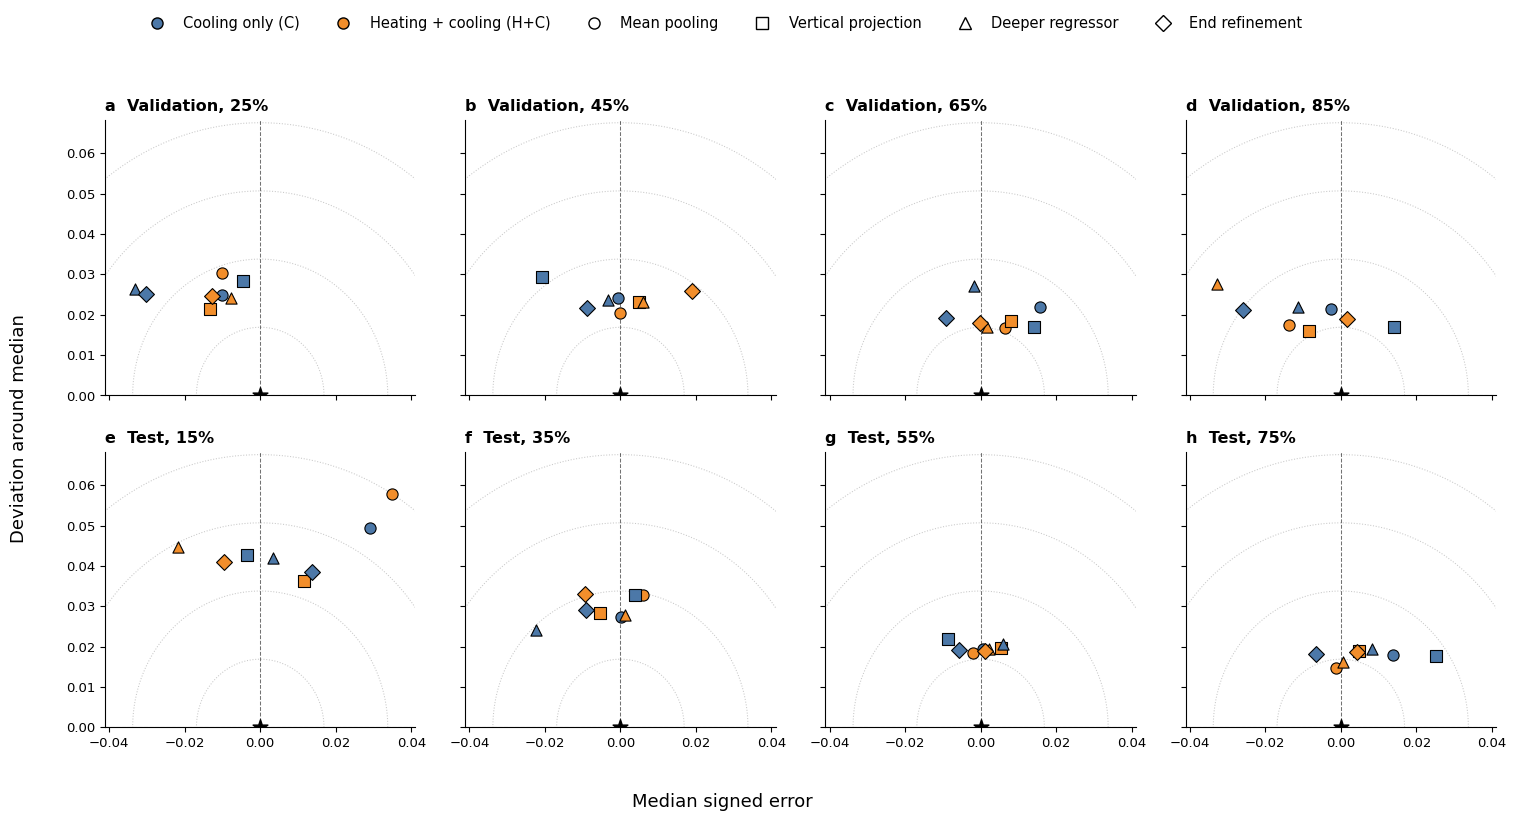

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D


# ---------------------------------------------------------
# Plot styling
# ---------------------------------------------------------
COLORS = {
    "C": "#4C78A8",
    "H+C": "#F28E2B",
}

MODEL_LABELS = {
    "Bnet-Mean": "Mean pooling",
    "Bnet-Vertical projection": "Vertical projection",
    "Bnet-Deeper regressor": "Deeper regressor",
    "Bnet-End refinement": "End refinement",
}

MODEL_MARKERS = {
    "Bnet-Mean": "o",
    "Bnet-Vertical projection": "s",
    "Bnet-Deeper regressor": "^",
    "Bnet-End refinement": "D",
}

MODEL_ORDER = [
    "Bnet-Mean",
    "Bnet-Vertical projection",
    "Bnet-Deeper regressor",
    "Bnet-End refinement",
]

MODE_ORDER = ["C", "H+C"]


# ---------------------------------------------------------
# Panel arrangement
# ---------------------------------------------------------
PANEL_CONFIGURATION = [
    ("Validation", 25),
    ("Validation", 45),
    ("Validation", 65),
    ("Validation", 85),
    ("Test", 15),
    ("Test", 35),
    ("Test", 55),
    ("Test", 75),
]

PANEL_LABELS = list("abcdefgh")


# ---------------------------------------------------------
# Common axis limits
# ---------------------------------------------------------
maximum_x = conditioned_df[
    "Median signed error"
].abs().max()

maximum_y = conditioned_df[
    "Std around median"
].max()

maximum_distance = conditioned_df[
    "Origin distance"
].max()

x_limit = maximum_x * 1.18
y_limit = maximum_y * 1.18


# ---------------------------------------------------------
# Create the 2 × 4 figure
# ---------------------------------------------------------
fig, axes = plt.subplots(
    2,
    4,
    figsize=(16.0, 8.6),
    sharex=True,
    sharey=True,
)

axes = axes.flatten()


# ---------------------------------------------------------
# Plot individual depth panels
# ---------------------------------------------------------
for ax, panel_configuration, panel_label in zip(
    axes,
    PANEL_CONFIGURATION,
    PANEL_LABELS,
):
    dataset, depth = panel_configuration

    selected_depth = conditioned_df[
        (conditioned_df["Dataset"] == dataset)
        & (conditioned_df["Depth [%]"] == depth)
    ]

    # -----------------------------------------------------
    # Equal-distance contours
    # -----------------------------------------------------
    contour_radii = np.linspace(
        maximum_distance / 4,
        maximum_distance,
        4,
    )

    theta = np.linspace(0, np.pi, 300)

    for radius in contour_radii:
        contour_x = radius * np.cos(theta)
        contour_y = radius * np.sin(theta)

        ax.plot(
            contour_x,
            contour_y,
            color="#C8C8C8",
            linestyle=":",
            linewidth=0.75,
            zorder=0,
        )

    # -----------------------------------------------------
    # Eight model–mode configurations
    # -----------------------------------------------------
    for model in MODEL_ORDER:
        for mode in MODE_ORDER:
            observation = selected_depth[
                (selected_depth["Model"] == model)
                & (selected_depth["Mode"] == mode)
            ]

            if observation.empty:
                continue

            ax.scatter(
                observation["Median signed error"],
                observation["Std around median"],
                s=65,
                marker=MODEL_MARKERS[model],
                facecolor=COLORS[mode],
                edgecolor="black",
                linewidth=0.8,
                zorder=3,
            )

    # -----------------------------------------------------
    # Ideal point
    # -----------------------------------------------------
    ax.scatter(
        0,
        0,
        marker="*",
        s=125,
        facecolor="black",
        edgecolor="black",
        zorder=5,
    )

    ax.axvline(
        0,
        color="black",
        linestyle="--",
        linewidth=0.75,
        alpha=0.55,
        zorder=1,
    )

    ax.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=0.75,
        alpha=0.55,
        zorder=1,
    )

    # -----------------------------------------------------
    # Panel formatting
    # -----------------------------------------------------
    ax.set_xlim(-x_limit, x_limit)
    ax.set_ylim(0, y_limit)

    ax.set_title(
        f"{panel_label}  {dataset}, {depth}%",
        loc="left",
        fontsize=11.5,
        fontweight="bold",
    )

    ax.tick_params(
        axis="both",
        labelsize=9.5,
    )

    ax.grid(False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


# ---------------------------------------------------------
# Shared axis labels
# ---------------------------------------------------------
fig.supxlabel(
    "Median signed error",
    fontsize=13,
    y=0.055,
)

fig.supylabel(
    "Deviation around median",
    fontsize=13,
    x=0.055,
)


# ---------------------------------------------------------
# Legends
# ---------------------------------------------------------
mode_handles = [
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        markerfacecolor=COLORS["C"],
        markeredgecolor="black",
        markersize=8,
        label="Cooling only (C)",
    ),
    Line2D(
        [0],
        [0],
        marker="o",
        linestyle="None",
        markerfacecolor=COLORS["H+C"],
        markeredgecolor="black",
        markersize=8,
        label="Heating + cooling (H+C)",
    ),
]

model_handles = [
    Line2D(
        [0],
        [0],
        marker=MODEL_MARKERS[model],
        linestyle="None",
        markerfacecolor="white",
        markeredgecolor="black",
        markersize=8,
        label=MODEL_LABELS[model],
    )
    for model in MODEL_ORDER
]

fig.legend(
    handles=mode_handles + model_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, 0.995),
    ncol=6,
    frameon=False,
    fontsize=10.5,
)


# ---------------------------------------------------------
# Layout and export
# ---------------------------------------------------------
fig.tight_layout(
    rect=[0.06, 0.07, 1.0, 0.90],
    w_pad=1.6,
    h_pad=2.0,
)

plt.savefig(
    "depth_conditioned_error_scatter_8_panels.pdf",
    bbox_inches="tight",
)

plt.savefig(
    "depth_conditioned_error_scatter_8_panels.png",
    dpi=600,
    bbox_inches="tight",
)

plt.show()

In [36]:
def display_distance_ranking(ranking, title):
    distance_columns = [
        column
        for column in ranking.columns
        if (
            "distance" in column.lower()
            or column in [
                "Mean_signed_median",
                "Mean_absolute_signed_median",
                "Mean_std",
            ]
        )
    ]

    def colour_mode(series):
        return [
            (
                "background-color: #DCEAF5; color: #1F4E79;"
                if value == "Cooling only (C)"
                else "background-color: #FCE4D6; color: #9C4A09;"
            )
            for value in series
        ]

    styled = (
        ranking.style
        .format({
            column: "{:.5f}"
            for column in distance_columns
        })
        .apply(
            colour_mode,
            subset=["Mode"],
        )
        .apply(
            lambda row: [
                "font-weight: bold;" if row["Rank"] == 1 else ""
                for _ in row
            ],
            axis=1,
        )
        .hide(axis="index")
        .set_caption(title)
    )

    display(styled)


display_distance_ranking(
    validation_distance_ranking,
    "Validation ranking based on distance from the ideal point",
)

display_distance_ranking(
    test_distance_ranking,
    "Test ranking based on distance from the ideal point",
)

Rank,Model,Mode,Mean_signed_median,Mean_absolute_signed_median,Mean_std,Mean_origin_distance,Worst_origin_distance,Distance at 25%,Distance at 45%,Distance at 65%,Distance at 85%
1,Vertical projection,Heating + cooling (H+C),-0.00214,0.00868,0.01974,0.02175,0.02516,0.02516,0.02364,0.02007,0.01814
2,Mean pooling,Heating + cooling (H+C),-0.00434,0.00759,0.02121,0.02312,0.03199,0.03199,0.02046,0.01784,0.02220
3,End refinement,Heating + cooling (H+C),0.00194,0.00831,0.02182,0.02416,0.03202,0.02770,0.03202,0.01799,0.01893
4,Mean pooling,Cooling only (C),0.00055,0.00730,0.02315,0.02495,0.02694,0.02693,0.02427,0.02694,0.02166
5,Deeper regressor,Heating + cooling (H+C),-0.00813,0.01204,0.02291,0.02723,0.04274,0.02530,0.02387,0.01701,0.04274
6,Vertical projection,Cooling only (C),0.00074,0.01343,0.02293,0.02725,0.03594,0.02882,0.03594,0.02211,0.02211
7,End refinement,Cooling only (C),-0.01852,0.01852,0.02177,0.02933,0.03942,0.03942,0.02328,0.02131,0.03333
8,Deeper regressor,Cooling only (C),-0.01237,0.01237,0.02474,0.02951,0.04241,0.04241,0.02391,0.02710,0.02464


Rank,Model,Mode,Mean_signed_median,Mean_absolute_signed_median,Mean_std,Mean_origin_distance,Worst_origin_distance,Distance at 15%,Distance at 35%,Distance at 55%,Distance at 75%
1,Vertical projection,Heating + cooling (H+C),0.00413,0.00683,0.02577,0.02669,0.03801,0.03801,0.02880,0.02048,0.01948
2,End refinement,Cooling only (C),-0.00194,0.00879,0.02619,0.02763,0.04086,0.04086,0.03033,0.02004,0.01929
3,Deeper regressor,Heating + cooling (H+C),-0.00449,0.00642,0.02703,0.02833,0.04968,0.04968,0.02785,0.01961,0.01617
4,End refinement,Heating + cooling (H+C),-0.00335,0.00608,0.02790,0.02862,0.04204,0.04204,0.03433,0.01889,0.01924
5,Deeper regressor,Cooling only (C),-0.00113,0.01000,0.02652,0.02936,0.04203,0.04203,0.03284,0.02160,0.02098
6,Mean pooling,Cooling only (C),0.01091,0.01091,0.02849,0.03166,0.05730,0.05730,0.02734,0.01933,0.02265
7,Vertical projection,Cooling only (C),0.00423,0.01025,0.02879,0.03254,0.04290,0.04290,0.03302,0.02357,0.03069
8,Mean pooling,Heating + cooling (H+C),0.00938,0.01101,0.03098,0.03357,0.06756,0.06756,0.03336,0.01865,0.01469


In [37]:
import numpy as np
import pandas as pd


# ---------------------------------------------------------
# Configuration
# ---------------------------------------------------------
MODEL_LABELS = {
    "Bnet-Mean": "Mean pooling",
    "Bnet-Vertical projection": "Vertical projection",
    "Bnet-Deeper regressor": "Deeper regressor",
    "Bnet-End refinement": "End refinement",
}

DEPTH_GROUPS = {
    "Validation": [
        (25, ""),
        (45, ".1"),
        (65, ".2"),
        (85, ".3"),
    ],
    "Test": [
        (15, ".4"),
        (35, ".5"),
        (55, ".6"),
        (75, ".7"),
    ],
}


# ---------------------------------------------------------
# Convert depth-conditioned metrics to long format
# ---------------------------------------------------------
metric_records = []

for _, row in iou_df.iterrows():
    model = row["Analysis model"]
    mode = str(row["Analysis mode"])

    for dataset, depth_groups in DEPTH_GROUPS.items():
        for depth, suffix in depth_groups:
            mae_column = f"MAE [mm]{suffix}"
            medae_column = f"MedAE [mm]{suffix}"
            rmse_column = f"RMSE [mm]{suffix}"

            mae = pd.to_numeric(
                row[mae_column],
                errors="coerce",
            )

            medae = pd.to_numeric(
                row[medae_column],
                errors="coerce",
            )

            rmse = pd.to_numeric(
                row[rmse_column],
                errors="coerce",
            )

            if pd.isna(mae) or pd.isna(medae) or pd.isna(rmse):
                continue

            metric_records.append({
                "Dataset": dataset,
                "Depth [%]": depth,
                "Model": model,
                "Mode": mode,
                "MAE [mm]": mae,
                "MedAE [mm]": medae,
                "RMSE [mm]": rmse,
            })

metric_df = pd.DataFrame(metric_records)

print("Depth-conditioned metric observations:", len(metric_df))

display(metric_df.head())

Depth-conditioned metric observations: 64


,Dataset,Depth [%],Model,Mode,MAE [mm],MedAE [mm],RMSE [mm]
0,Validation,25,Bnet-Mean,C,0.071231,0.058054,0.106059
1,Validation,45,Bnet-Mean,C,0.057506,0.038668,0.069598
2,Validation,65,Bnet-Mean,C,0.066778,0.069598,0.096864
3,Validation,85,Bnet-Mean,C,0.052997,0.040459,0.081156
4,Test,15,Bnet-Mean,C,0.225683,0.145931,0.275911


In [38]:
def sequential_rank(table, sort_columns):
    """
    Produce unique ranks from 1 to N using the specified
    sorting order.
    """
    ordered_indices = (
        table
        .sort_values(
            by=sort_columns,
            ascending=[True] * len(sort_columns),
        )
        .index
        .tolist()
    )

    rank_mapping = {
        original_index: rank
        for rank, original_index
        in enumerate(ordered_indices, start=1)
    }

    return table.index.map(rank_mapping)


def create_metric_ranking(data, dataset):
    selected = data[
        data["Dataset"] == dataset
    ].copy()

    # Equal weighting of the four evaluated depths
    ranking = (
        selected.groupby(
            ["Model", "Mode"],
            observed=True,
        )
        .agg(
            Mean_MAE=("MAE [mm]", "mean"),
            Mean_MedAE=("MedAE [mm]", "mean"),
            Mean_RMSE=("RMSE [mm]", "mean"),
        )
        .reset_index()
    )

    # -----------------------------------------------------
    # Individual metric ranks
    # -----------------------------------------------------
    ranking["MAE metric rank"] = ranking[
        "Mean_MAE"
    ].rank(
        method="average",
        ascending=True,
    )

    ranking["MedAE metric rank"] = ranking[
        "Mean_MedAE"
    ].rank(
        method="average",
        ascending=True,
    )

    ranking["RMSE metric rank"] = ranking[
        "Mean_RMSE"
    ].rank(
        method="average",
        ascending=True,
    )

    # -----------------------------------------------------
    # Average-rank scores
    # -----------------------------------------------------
    ranking["MAE–RMSE rank score"] = (
        ranking["MAE metric rank"]
        + ranking["RMSE metric rank"]
    ) / 2

    ranking["MedAE–RMSE rank score"] = (
        ranking["MedAE metric rank"]
        + ranking["RMSE metric rank"]
    ) / 2

    # -----------------------------------------------------
    # Ranking 1: MAE and RMSE
    #
    # Tiebreakers:
    # 1. Lower RMSE
    # 2. Lower MAE
    # -----------------------------------------------------
    ranking["Rank: MAE + RMSE"] = sequential_rank(
        ranking,
        [
            "MAE–RMSE rank score",
            "Mean_RMSE",
            "Mean_MAE",
        ],
    )

    # -----------------------------------------------------
    # Ranking 2: MedAE and RMSE
    #
    # Tiebreakers:
    # 1. Lower RMSE
    # 2. Lower MedAE
    # -----------------------------------------------------
    ranking["Rank: MedAE + RMSE"] = sequential_rank(
        ranking,
        [
            "MedAE–RMSE rank score",
            "Mean_RMSE",
            "Mean_MedAE",
        ],
    )

    # Sort by the MedAE–RMSE ranking
    ranking = (
        ranking
        .sort_values(
            by="Rank: MedAE + RMSE",
            ascending=True,
        )
        .reset_index(drop=True)
    )

    ranking["Model"] = ranking["Model"].map(
        MODEL_LABELS
    ).fillna(ranking["Model"])

    ranking["Mode"] = ranking["Mode"].replace({
        "C": "Cooling only (C)",
        "H+C": "Heating + cooling (H+C)",
    })

    return ranking


validation_metric_ranking = create_metric_ranking(
    metric_df,
    "Validation",
)

test_metric_ranking = create_metric_ranking(
    metric_df,
    "Test",
)

In [39]:
TABLE_COLUMNS = [
    "Rank: MAE + RMSE",
    "Rank: MedAE + RMSE",
    "Model",
    "Mode",
    "Mean_MAE",
    "Mean_MedAE",
    "Mean_RMSE",
    "MAE–RMSE rank score",
    "MedAE–RMSE rank score",
]


def prepare_display_table(ranking):
    table = ranking[TABLE_COLUMNS].copy()

    table = table.rename(columns={
        "Mean_MAE": "Mean MAE [mm]",
        "Mean_MedAE": "Mean MedAE [mm]",
        "Mean_RMSE": "Mean RMSE [mm]",
    })

    return table


validation_table = prepare_display_table(
    validation_metric_ranking
)

test_table = prepare_display_table(
    test_metric_ranking
)

In [40]:
def display_metric_table(table, caption):
    def colour_mode(series):
        styles = []

        for value in series:
            if value == "Cooling only (C)":
                styles.append(
                    "background-color: #DCEAF5; "
                    "color: #1F4E79;"
                )
            else:
                styles.append(
                    "background-color: #FCE4D6; "
                    "color: #9C4A09;"
                )

        return styles

    styled = (
        table.style
        .format({
            "Mean MAE [mm]": "{:.4f}",
            "Mean MedAE [mm]": "{:.4f}",
            "Mean RMSE [mm]": "{:.4f}",
            "MAE–RMSE rank score": "{:.2f}",
            "MedAE–RMSE rank score": "{:.2f}",
        })
        .apply(
            colour_mode,
            subset=["Mode"],
        )
        .apply(
            lambda row: [
                (
                    "font-weight: bold;"
                    if row["Rank: MedAE + RMSE"] == 1
                    else ""
                )
                for _ in row
            ],
            axis=1,
        )
        .hide(axis="index")
        .set_caption(caption)
    )

    display(styled)


display_metric_table(
    validation_table,
    "Validation ranking based on depth-estimation errors",
)

display_metric_table(
    test_table,
    "Test ranking based on depth-estimation errors",
)

Rank: MAE + RMSE,Rank: MedAE + RMSE,Model,Mode,Mean MAE [mm],Mean MedAE [mm],Mean RMSE [mm],MAE–RMSE rank score,MedAE–RMSE rank score
2,1,Vertical projection,Heating + cooling (H+C),0.0538,0.0415,0.0973,1.50,1.50
1,2,Mean pooling,Cooling only (C),0.0621,0.0517,0.0884,1.50,2.50
4,3,Vertical projection,Cooling only (C),0.0743,0.0655,0.1057,4.50,4.50
3,4,Deeper regressor,Heating + cooling (H+C),0.0714,0.0647,0.1074,4.00,4.50
5,5,Mean pooling,Heating + cooling (H+C),0.0660,0.0514,0.1216,4.50,4.50
7,6,End refinement,Heating + cooling (H+C),0.0714,0.0496,0.1502,6.50,5.00
6,7,End refinement,Cooling only (C),0.0819,0.0685,0.1203,6.00,6.00
8,8,Deeper regressor,Cooling only (C),0.0926,0.0733,0.1450,7.50,7.50


Rank: MAE + RMSE,Rank: MedAE + RMSE,Model,Mode,Mean MAE [mm],Mean MedAE [mm],Mean RMSE [mm],MAE–RMSE rank score,MedAE–RMSE rank score
1,1,Vertical projection,Heating + cooling (H+C),0.0816,0.0418,0.1439,1.00,1.00
2,2,Mean pooling,Cooling only (C),0.1043,0.0650,0.1629,2.50,3.50
5,3,End refinement,Cooling only (C),0.1044,0.0565,0.1866,4.00,3.50
4,4,Mean pooling,Heating + cooling (H+C),0.1079,0.0696,0.1750,4.00,4.50
6,5,End refinement,Heating + cooling (H+C),0.1121,0.0643,0.1917,6.00,4.50
3,6,Deeper regressor,Heating + cooling (H+C),0.1099,0.0988,0.1560,3.50,5.00
7,7,Vertical projection,Cooling only (C),0.1467,0.0925,0.2177,7.00,7.00
8,8,Deeper regressor,Cooling only (C),0.1657,0.0922,0.2535,8.00,7.00
